# Análisis Exploratorio - Proyecto Base de Datos - MDS7103
## Proyecto "Análisis de base de datos de establecimientos educaciones en Chile"

In [34]:
## Configuraciones

### Librerias
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os 

### Directorio 

path = 'C:/Users/bruno/OneDrive/Documentos/Base de datos/PROYECTO BBDD/'
os.chdir(path)

### Conexión

conn = psycopg2.connect(
    host='localhost',
    port=5432,
    user='postgres',
    password='admin1234',
    database='ESTABLECIMIENTOS_EDUCACIONALES',
    options='-c search_path=educacion'
)
### Configuración de gráficos
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})
PALETTE = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2"]

### Pregunta 1

In [28]:
Q1 = '''
WITH establecimientos_tp AS (
    SELECT DISTINCT en.e_RBD
    FROM establecimiento_nivel en
    WHERE en.n_ID_NIVEL IN (7, 8)
    UNION
    SELECT DISTINCT ee.e_RBD
    FROM establecimiento_ensenanza ee
    WHERE ee.en_COD_ENSE IN (410,460,461,463, 510,560,561,563,
                             610,660,661,663, 710,760,761,763,
                             810,860,863)
)
SELECT
    r.NOM_REG_RBD                                        AS region,
    COUNT(DISTINCT etp.e_RBD)                            AS n_estab_tp,
    ROUND(100.0 * COUNT(DISTINCT etp.e_RBD)
          / NULLIF(SUM(COUNT(DISTINCT etp.e_RBD)) OVER (), 0), 2) AS pct_del_total_tp,
    RANK() OVER (ORDER BY COUNT(DISTINCT etp.e_RBD) DESC)         AS ranking
FROM region r
LEFT JOIN provincia p        ON p.r_COD_REG_RBD = r.COD_REG_RBD
LEFT JOIN comuna c           ON c.p_COD_PRO_RBD = p.COD_PRO_RBD
LEFT JOIN establecimiento e  ON e.c_COD_COM_RBD = c.COD_COM_RBD
LEFT JOIN establecimientos_tp etp ON etp.e_RBD = e.RBD
GROUP BY r.NOM_REG_RBD
ORDER BY n_estab_tp DESC;
'''
df1 = pd.read_sql_query(Q1, conn)
df1

C:\Users\bruno\AppData\Local\Temp\ipykernel_4576\3677193656.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query(Q1, conn)


,region,n_estab_tp,pct_del_total_tp,ranking
0,RM,290,29.80,1
1,VALPO,97,9.97,2
2,ARAUC,81,8.32,3
3,BBIO,79,8.12,4
4,MAULE,71,7.30,5
5,LAGOS,64,6.58,6
6,LGBO,56,5.76,7
7,NUBLE,46,4.73,8
8,COQ,43,4.42,9
9,RIOS,34,3.49,10


FileNotFoundError: [Errno 2] No such file or directory: 'graficos/Consulta1.png'

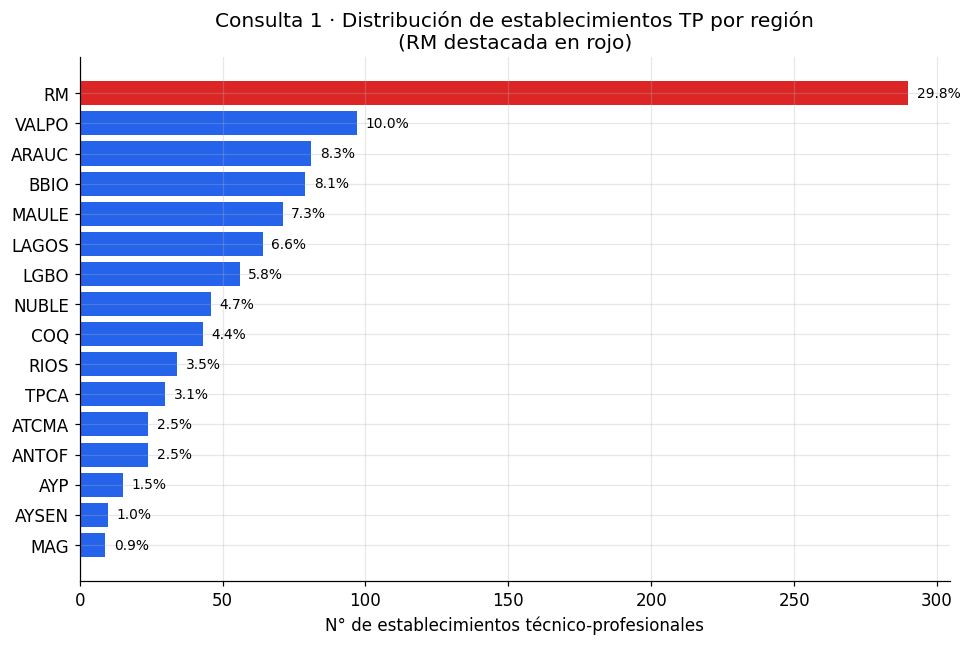

In [33]:
fig, ax = plt.subplots(figsize=(9, 6))
d = df1.sort_values("n_estab_tp")
colors = ["#dc2626" if "RM" in r else "#2563eb" for r in d["region"]]
bars = ax.barh(d["region"], d["n_estab_tp"], color=colors)
for b, p in zip(bars, d["pct_del_total_tp"]):
    ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f"{p:.1f}%",
            va="center", fontsize=9)
ax.set_xlabel("N° de establecimientos técnico-profesionales")
ax.set_title("Consulta 1 · Distribución de establecimientos TP por región\n(RM destacada en rojo)")
plt.tight_layout()
plt.savefig('graficos/Consulta1.png', dpi = 300)
plt.show()

rm = df1[df1["region"].str.contains("RM")]
if not rm.empty:
    print(f"La RM concentra el {rm['pct_del_total_tp'].iloc[0]:.1f}% de la oferta TP nacional (ranking #{int(rm['ranking'].iloc[0])}).")

### Pregunta 2

### Pregunta 3 (PARAMETRIZABLE)

### Pregunta 4

### Pregunta 5

### Pregunta 6